In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Shopping Trends And Customer Behaviour Dataset.csv")

## Snakecasing

In [3]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')

In [4]:
df

,unnamed:_0,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases
0,0,1,55,Male,Blouse,Clothing,53,Kentucky,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,1,2,19,Male,Sweater,Clothing,64,Maine,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,2,3,50,Male,Jeans,Clothing,73,Massachusetts,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,3,4,21,Male,Sandals,Footwear,90,Rhode Island,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,4,5,45,Male,Blouse,Clothing,49,Oregon,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3895,3896,40,Female,Hoodie,Clothing,28,Virginia,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3896,3897,52,Female,Backpack,Accessories,49,Iowa,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3897,3898,46,Female,Belt,Accessories,33,New Jersey,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3898,3899,44,Female,Shoes,Footwear,77,Minnesota,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   unnamed:_0              3900 non-null   int64  
 1   customer_id             3900 non-null   int64  
 2   age                     3900 non-null   int64  
 3   gender                  3900 non-null   object 
 4   item_purchased          3900 non-null   object 
 5   category                3900 non-null   object 
 6   purchase_amount_(usd)   3900 non-null   int64  
 7   location                3900 non-null   object 
 8   color                   3900 non-null   object 
 9   season                  3900 non-null   object 
 10  review_rating           3900 non-null   float64
 11  subscription_status     3900 non-null   object 
 12  shipping_type           3900 non-null   object 
 13  discount_applied        3900 non-null   object 
 14  promo_code_used         3900 non-null   

In [6]:
df.describe()

,unnamed:_0,customer_id,age,purchase_amount_(usd),review_rating,previous_purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1949.500000,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,1125.977353,15.207589,23.685392,0.716223,14.447125
min,0.000000,1.000000,18.000000,20.000000,2.500000,1.000000
25%,974.750000,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1949.500000,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2924.250000,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3899.000000,3900.000000,70.000000,100.000000,5.000000,50.000000


In [7]:
df.isnull().sum()

unnamed:_0                0
customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount_(usd)     0
location                  0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
dtype: int64

# Featuring some new coloumns

In [8]:
df["CLV"] = df["purchase_amount_(usd)"] * df["previous_purchases"]


In [9]:
df["Spending Level"] = pd.qcut(
    df["purchase_amount_(usd)"],
    q=3,
    labels=["Low", "Medium", "High"]
)


In [10]:
df["loyal_customer"] = df["previous_purchases"].apply(
    lambda x: "Yes" if x > 25 else "No"
)


In [11]:
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ['Teen', 'Young Adult', 'Adult', 'Mid-Age', 'Senior', 'Elder']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)


In [12]:
df['lifetime_value'] = (
    df['purchase_amount_(usd)'] * df['previous_purchases']
)


In [13]:
binary_cols = ['subscription_status','discount_applied','promo_code_used']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})


In [14]:
df['rating_category'] = pd.cut(df['review_rating'],bins=[0, 2.5, 3.5, 5],labels=['Poor', 'Average', 'Good'])


In [15]:
freq_map = {
    'Weekly': 4,
    'Fortnightly': 3,
    'Monthly': 2,
    'Annually': 1
}
df['purchase_frequency_score'] = df['frequency_of_purchases'].map(freq_map)

In [16]:
df.head()

,unnamed:_0,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,color,season,...,previous_purchases,payment_method,frequency_of_purchases,CLV,Spending Level,loyal_customer,age_group,lifetime_value,rating_category,purchase_frequency_score
0,0,1,55,Male,Blouse,Clothing,53,Kentucky,Gray,Winter,...,14,Venmo,Fortnightly,742,Medium,No,Senior,742,Average,3.0
1,1,2,19,Male,Sweater,Clothing,64,Maine,Maroon,Winter,...,2,Cash,Fortnightly,128,Medium,No,Young Adult,128,Average,3.0
2,2,3,50,Male,Jeans,Clothing,73,Massachusetts,Maroon,Spring,...,23,Credit Card,Weekly,1679,Medium,No,Senior,1679,Average,4.0
3,3,4,21,Male,Sandals,Footwear,90,Rhode Island,Maroon,Spring,...,49,PayPal,Weekly,4410,High,Yes,Young Adult,4410,Average,4.0
4,4,5,45,Male,Blouse,Clothing,49,Oregon,Turquoise,Spring,...,31,PayPal,Annually,1519,Medium,Yes,Mid-Age,1519,Average,1.0


## Dropping some old columns

In [17]:
col = ['unnamed:_0','age','frequency_of_purchases','review_rating','color','payment_method','shipping_type']
df.drop(columns=(col),axis=1,inplace=True)

In [18]:
df.head(5)

,customer_id,gender,item_purchased,category,purchase_amount_(usd),location,season,subscription_status,discount_applied,promo_code_used,previous_purchases,CLV,Spending Level,loyal_customer,age_group,lifetime_value,rating_category,purchase_frequency_score
0,1,Male,Blouse,Clothing,53,Kentucky,Winter,1,1,1,14,742,Medium,No,Senior,742,Average,3.0
1,2,Male,Sweater,Clothing,64,Maine,Winter,1,1,1,2,128,Medium,No,Young Adult,128,Average,3.0
2,3,Male,Jeans,Clothing,73,Massachusetts,Spring,1,1,1,23,1679,Medium,No,Senior,1679,Average,4.0
3,4,Male,Sandals,Footwear,90,Rhode Island,Spring,1,1,1,49,4410,High,Yes,Young Adult,4410,Average,4.0
4,5,Male,Blouse,Clothing,49,Oregon,Spring,1,1,1,31,1519,Medium,Yes,Mid-Age,1519,Average,1.0


# Visualization using Matplotlib & Seaborn

## 1.Correlation Heatmap

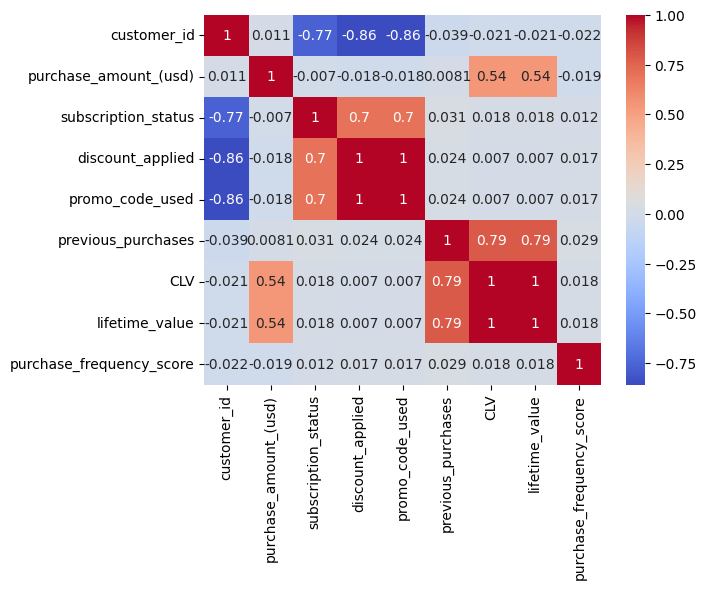

In [19]:

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()


## 2.Revenue by Category using Bar Chart

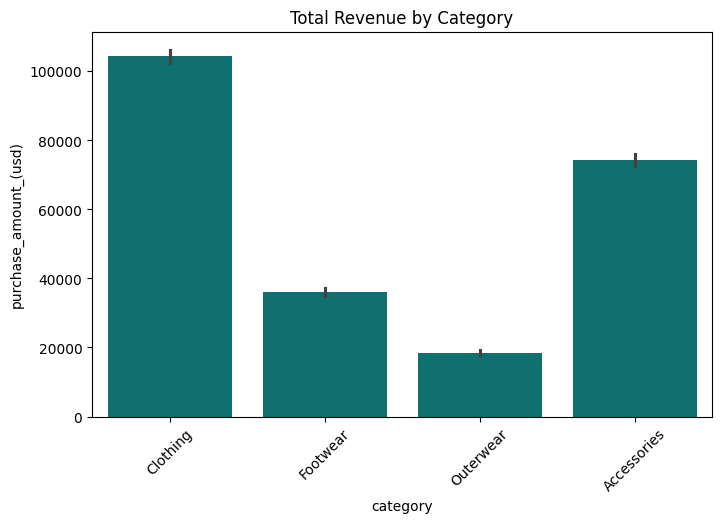

In [20]:

plt.figure(figsize=(8,5))
sns.barplot(x='category', y='purchase_amount_(usd)', data=df, estimator=sum,color='teal')
plt.title("Total Revenue by Category")
plt.xticks(rotation=45)
plt.show()

## 3.Revenue Contribution by Category using Pie Chart

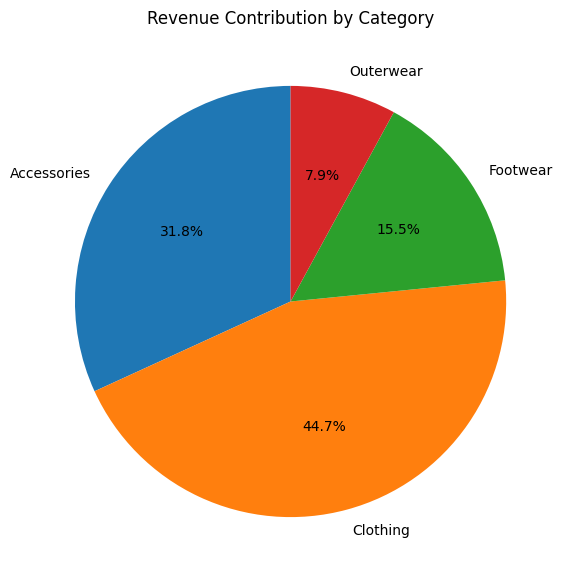

In [21]:
category_revenue = df.groupby('category')['purchase_amount_(usd)'].sum()

plt.figure(figsize=(7,7))
plt.pie(category_revenue,
        labels=category_revenue.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Revenue Contribution by Category")
plt.show()


## 4.Revenue by Location (Top 10 States)

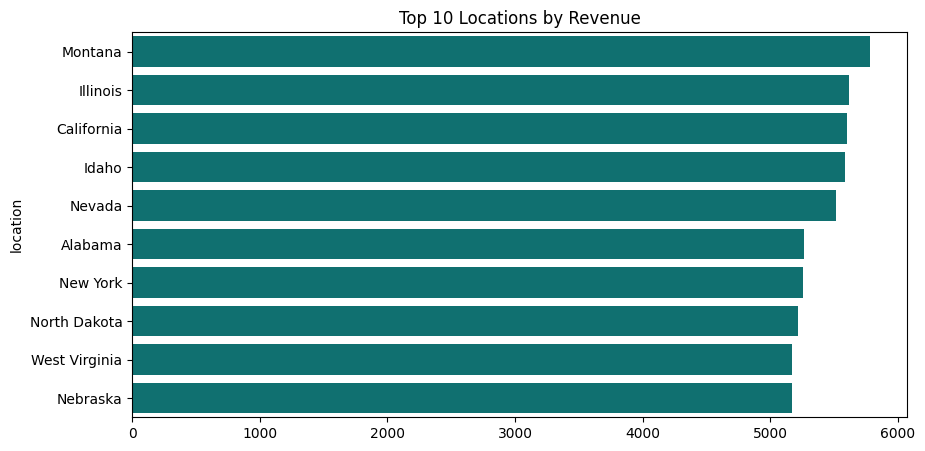

In [22]:
top_states = df.groupby('location')['purchase_amount_(usd)'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_states.values, y=top_states.index,color='teal')
plt.title("Top 10 Locations by Revenue")
plt.show()


## 5.Season vs Revenue using Bar Chart

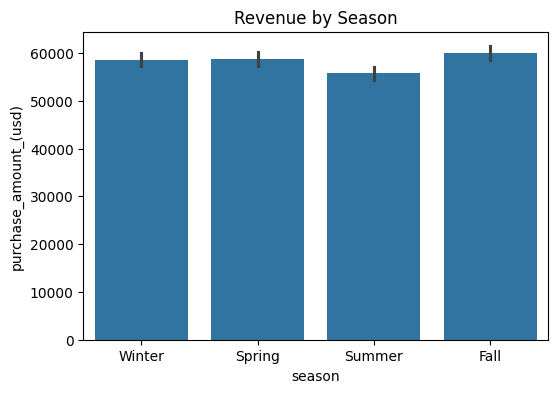

In [23]:
plt.figure(figsize=(6,4))
sns.barplot(x='season', y='purchase_amount_(usd)', data=df, estimator=sum)
plt.title("Revenue by Season")
plt.show()


## 6.CLV Distribution using Histogram

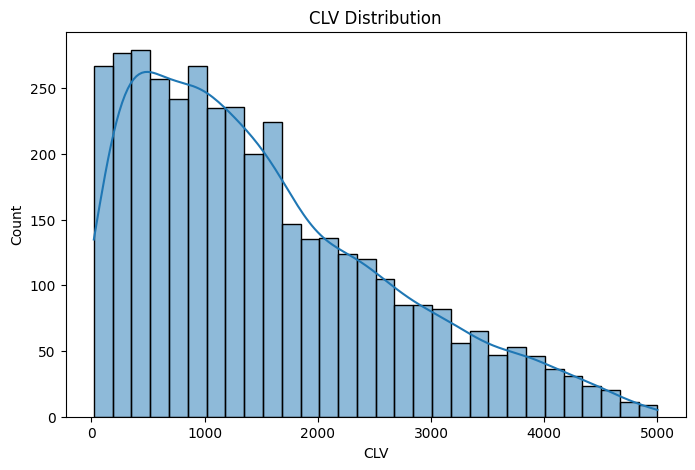

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['CLV'], bins=30, kde=True)
plt.title("CLV Distribution")
plt.show()



## 7.Loyal vs Non-Loyal Customers using Pie Chart

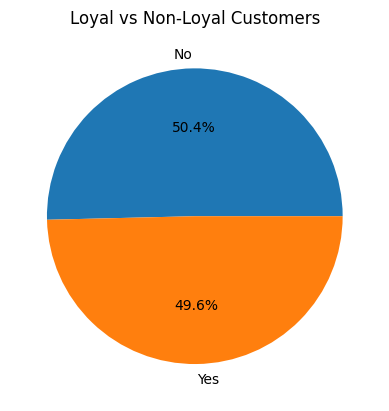

In [25]:
df['loyal_customer'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Loyal vs Non-Loyal Customers")
plt.ylabel("")
plt.show()


## 8.Season vs Revenue using Bar Chart

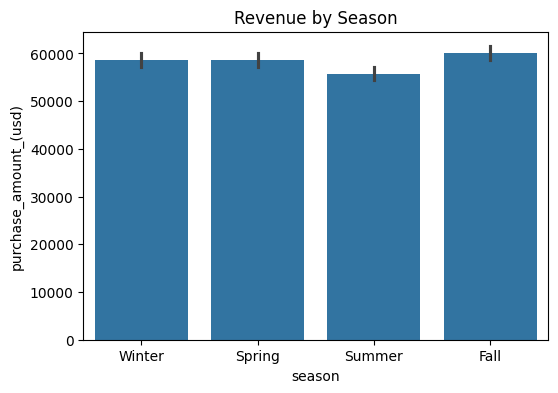

In [26]:
plt.figure(figsize=(6,4))
sns.barplot(x='season', y='purchase_amount_(usd)', data=df, estimator=sum)
plt.title("Revenue by Season")
plt.show()


## 9.Discount Impact on Purchase Amount using Boxplot

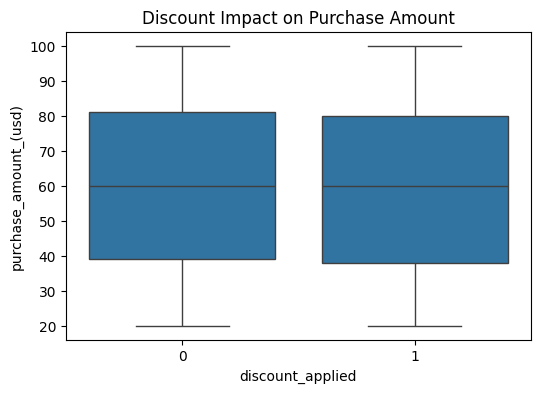

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x='discount_applied', y='purchase_amount_(usd)', data=df)
plt.title("Discount Impact on Purchase Amount")
plt.show()


## 10.Spending Level Distribution using Pie Chart

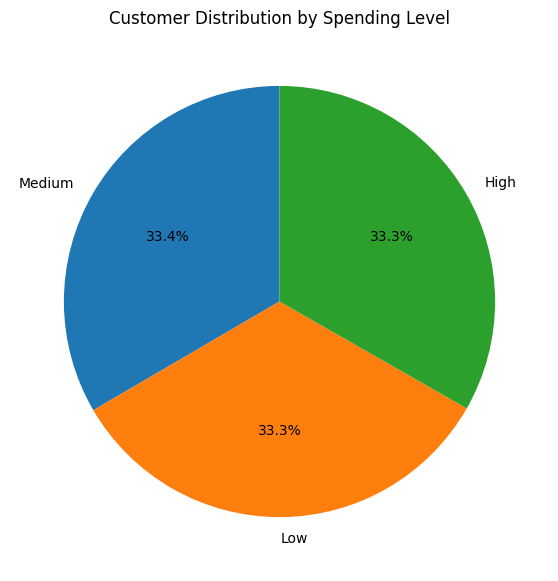

In [28]:
spending_dist = df['Spending Level'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(spending_dist,
        labels=spending_dist.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Customer Distribution by Spending Level")
plt.show()



# Connecting to SQL Database

In [29]:
import mysql.connector
import pandas as pd
from sqlalchemy import create_engine
connect = mysql.connector.connect( host = "localhost", user = "root", password = "Saurabh1234", database = "Shopping_Trends_And_Customer_Behaviour"  )

In [30]:
# MySQL connection details
username = "root"
password = "Saurabh1234"
host = "localhost"
port = "3306"
database = "Shopping_Trends_And_Customer_Behaviour"

# Engine
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# DataFrame to MySQL
table_name = "shopping_trends_and_customer_behaviour_table"  # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

# Reading 5 rows by SQL Querey
pd.read_sql("SELECT * FROM shopping_trends_and_customer_behaviour_table LIMIT 5 ;",engine)

,customer_id,gender,item_purchased,category,purchase_amount_(usd),location,season,subscription_status,discount_applied,promo_code_used,previous_purchases,CLV,Spending Level,loyal_customer,age_group,lifetime_value,rating_category,purchase_frequency_score
0,1,Male,Blouse,Clothing,53,Kentucky,Winter,1,1,1,14,742,Medium,No,Senior,742,Average,3.0
1,2,Male,Sweater,Clothing,64,Maine,Winter,1,1,1,2,128,Medium,No,Young Adult,128,Average,3.0
2,3,Male,Jeans,Clothing,73,Massachusetts,Spring,1,1,1,23,1679,Medium,No,Senior,1679,Average,4.0
3,4,Male,Sandals,Footwear,90,Rhode Island,Spring,1,1,1,49,4410,High,Yes,Young Adult,4410,Average,4.0
4,5,Male,Blouse,Clothing,49,Oregon,Spring,1,1,1,31,1519,Medium,Yes,Mid-Age,1519,Average,1.0


# Converting DataFrame Into CSV for Power BI

In [32]:
df.to_csv("Final_csv.csv",index = False)